# 3D Inversion Cube Viewer

This notebook renders a 3D cube with three orthogonal slices (IL / XL / S).

Key rendering choices in this version:
- X/Y/Z are shown in index coordinates by default
- slice textures are smoothed by Gaussian + spline-like interpolation
- `plot_surface` is forced to use the **full interpolated surface resolution** instead of matplotlib's default heavy downsampling


In [47]:
from pathlib import Path

NPY_PATH = Path(r"H:\AGPE-Inv_FINAL\AGPE-Inv_FINAL-main\results\paper_ablation_20260308_191828_636300\05_proposed\VishalNet_cov_para_Facies_skel_ref_nobddep_awgntrain_rdrop_s_uns_Stanford_VI_pred_AI.npy")
REFERENCE_NPY = Path(r"H:\AGPE-Inv_FINAL\AGPE-Inv_FINAL-main\data\Stanford_VI\synth_40HZ.npy")
INPUT_MODE = "auto"  # auto | flat_pred | cube3d
CUBE_MAPPING = (2, 1, 0)

IL_SLICE = 199
XL_SLICE = 0
S_SLICE = 100

DISPLAY_IN_INDEX_UNITS = True
X_TICK_STEP_IDX = 25
Y_TICK_STEP_IDX = 25
Z_TICK_STEP_IDX = 20

CMAP = "viridis"
VMIN = None
VMAX = None
ROBUST_CLIP = (1.0, 99.0)

# Rendering quality knobs
FIGSIZE = (13, 9)
DPI = 320
ELEV = 31
AZIM = -58
ROLL = 0
Z_ASPECT_SCALE = 0.42  # <1 compresses vertical extent

# Main anti-pixelation controls
SURFACE_SMOOTH_FACTOR = 3.0   # base upsampling for vertical walls
HORIZONTAL_SMOOTH_FACTOR = 4.5  # stronger smoothing for the plan view
SURFACE_SMOOTH_ORDER = 3
SURFACE_GAUSSIAN_SIGMA = 0.65
MAX_SURFACE_POINTS = 300000

# Make the horizontal slice visually dominant
HORIZONTAL_ALPHA = 1.00
VERTICAL_ALPHA = 0.82

TITLE = "3D Inversion Cube"
SHOW_COLORBAR = True
SHOW_BOX = True
OUTPUT_PNG = None



In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from mpl_toolkits.mplot3d import Axes3D
from scipy import ndimage

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"


def load_cube_ilxls(npy_path, input_mode="auto", reference_npy=None, cube_mapping=(2, 1, 0)):
    arr = np.load(npy_path)
    mode = input_mode
    if mode == "auto":
        mode = "flat_pred" if arr.ndim == 2 else "cube3d"

    if mode == "cube3d":
        if arr.ndim != 3:
            raise ValueError(f"cube3d mode expects a 3D array, got {arr.shape}")
        cube = np.transpose(arr, cube_mapping).astype(np.float32, copy=False)
        meta = {
            "mode": "cube3d",
            "input_shape": tuple(arr.shape),
            "cube_shape": tuple(cube.shape),
            "reference_npy": None,
        }
        return cube, meta

    if mode != "flat_pred":
        raise ValueError(f"unsupported input mode: {mode}")

    if arr.ndim != 2:
        raise ValueError(f"flat_pred mode expects a 2D array, got {arr.shape}")
    if reference_npy is None:
        raise ValueError("flat_pred mode requires REFERENCE_NPY")

    ref = np.load(reference_npy, mmap_mode="r")
    if ref.ndim != 3:
        raise ValueError(f"reference cube must be 3D, got {ref.shape}")

    h, il, xl = ref.shape
    expected_traces = il * xl
    if arr.shape == (expected_traces, h):
        cube = arr.reshape(il, xl, h)
    elif arr.shape == (h, expected_traces):
        cube = arr.T.reshape(il, xl, h)
    else:
        raise ValueError(
            f"cannot restore flat prediction {arr.shape}; expected ({expected_traces}, {h}) or ({h}, {expected_traces})"
        )

    cube = cube.astype(np.float32, copy=False)
    meta = {
        "mode": "flat_pred",
        "input_shape": tuple(arr.shape),
        "cube_shape": tuple(cube.shape),
        "reference_npy": str(reference_npy),
    }
    return cube, meta


def resolve_color_limits(cube, vmin=None, vmax=None, robust_clip=(1.0, 99.0)):
    if vmin is None:
        vmin = float(np.percentile(cube, robust_clip[0]))
    if vmax is None:
        vmax = float(np.percentile(cube, robust_clip[1]))
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return float(vmin), float(vmax)


def _style_3d_axes(ax):
    ax.grid(False)
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        try:
            axis.pane.fill = False
            axis.pane.set_edgecolor((0, 0, 0, 0))
        except Exception:
            pass


def draw_bbox(ax, xlim, ylim, zlim, color="black", lw=1.0, alpha=0.6):
    x0, x1 = xlim
    y0, y1 = ylim
    z0, z1 = zlim
    edges = [
        ((x0, y0, z0), (x1, y0, z0)), ((x0, y1, z0), (x1, y1, z0)),
        ((x0, y0, z1), (x1, y0, z1)), ((x0, y1, z1), (x1, y1, z1)),
        ((x0, y0, z0), (x0, y1, z0)), ((x1, y0, z0), (x1, y1, z0)),
        ((x0, y0, z1), (x0, y1, z1)), ((x1, y0, z1), (x1, y1, z1)),
        ((x0, y0, z0), (x0, y0, z1)), ((x1, y0, z0), (x1, y0, z1)),
        ((x0, y1, z0), (x0, y1, z1)), ((x1, y1, z0), (x1, y1, z1)),
    ]
    for p0, p1 in edges:
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], color=color, lw=lw, alpha=alpha)


def make_index_ticks(count, step):
    ticks = np.arange(0, count, max(1, int(step)))
    if ticks[-1] != count - 1:
        ticks = np.unique(np.append(ticks, count - 1))
    labels = [str(int(v)) for v in ticks]
    return ticks.astype(float), labels


def _cap_zoom_factor(shape2d, factor, max_points):
    if factor <= 1.0:
        return 1.0
    h, w = shape2d
    target_points = (h * factor) * (w * factor)
    if target_points <= max_points:
        return float(factor)
    return float((max_points / float(h * w)) ** 0.5)


def smooth_slice2d(arr2d, factor=1.0, order=3, sigma=0.55, max_points=300000):
    arr = arr2d.astype(np.float32, copy=False)
    if sigma and sigma > 0:
        arr = ndimage.gaussian_filter(arr, sigma=float(sigma), mode="nearest")

    fac = _cap_zoom_factor(arr.shape, float(factor), int(max_points))
    if fac > 1.0:
        arr = ndimage.zoom(arr, zoom=fac, order=int(order), mode="nearest")
        if sigma and sigma > 0:
            arr = ndimage.gaussian_filter(arr, sigma=float(sigma) * 0.4, mode="nearest")
    return arr


def make_surface_from_slice(slice2d, x_coords, y_coords, axis="horizontal", smooth_factor=1.0, smooth_order=3, gaussian_sigma=0.55, max_points=300000, fixed_coord=0.0):
    data = smooth_slice2d(slice2d, factor=smooth_factor, order=smooth_order, sigma=gaussian_sigma, max_points=max_points)
    x_dense = np.linspace(x_coords[0], x_coords[-1], data.shape[1])
    y_dense = np.linspace(y_coords[0], y_coords[-1], data.shape[0])

    if axis == "horizontal":
        X, Y = np.meshgrid(x_dense, y_dense)
        Z = np.full_like(X, fixed_coord, dtype=float)
        return X, Y, Z, data
    if axis == "inline":
        X, Z = np.meshgrid(x_dense, y_dense)
        Y = np.full_like(X, fixed_coord, dtype=float)
        return X, Y, Z, data
    if axis == "crossline":
        Y, Z = np.meshgrid(x_dense, y_dense)
        X = np.full_like(Y, fixed_coord, dtype=float)
        return X, Y, Z, data
    raise ValueError(f"unsupported axis: {axis}")


def plot_surface_fullres(ax, X, Y, Z, values, cmap_obj, norm, alpha=1.0):
    facecolors = cmap_obj(norm(values))
    facecolors[..., -1] = float(alpha)
    return ax.plot_surface(
        X, Y, Z,
        facecolors=facecolors,
        rcount=values.shape[0],
        ccount=values.shape[1],
        linewidth=0,
        edgecolor="none",
        antialiased=False,
        shade=False,
    )


def plot_cube_3slices(
    cube,
    il_slice,
    xl_slice,
    s_slice,
    cmap="viridis",
    vmin=None,
    vmax=None,
    robust_clip=(1.0, 99.0),
    figsize=(12, 9),
    dpi=260,
    elev=24,
    azim=-55,
    roll=0,
    title="3D Inversion Cube",
    show_colorbar=True,
    show_box=True,
    display_in_index_units=True,
    x_tick_step_idx=25,
    y_tick_step_idx=25,
    z_tick_step_idx=20,
    smooth_factor=2.5,
    horizontal_smooth_factor=None,
    smooth_order=3,
    gaussian_sigma=0.55,
    max_surface_points=300000,
    vertical_aspect_scale=0.42,
    horizontal_alpha=1.0,
    vertical_alpha=0.82,
    output_png=None,
):
    il_n, xl_n, s_n = cube.shape
    il_slice = int(np.clip(il_slice, 0, il_n - 1))
    xl_slice = int(np.clip(xl_slice, 0, xl_n - 1))
    s_slice = int(np.clip(s_slice, 0, s_n - 1))
    if horizontal_smooth_factor is None:
        horizontal_smooth_factor = smooth_factor

    x = np.arange(xl_n, dtype=float)
    y = np.arange(il_n, dtype=float)
    z = np.arange(s_n, dtype=float)
    xlim = (0.0, float(xl_n - 1))
    ylim = (0.0, float(il_n - 1))
    zlim = (0.0, float(s_n - 1))
    box_aspect = (xl_n, il_n, max(1.0, s_n * float(vertical_aspect_scale)))
    xlabel = "XL / X"
    ylabel = "IL / Y"
    zlabel = "S / Depth"

    vmin, vmax = resolve_color_limits(cube, vmin=vmin, vmax=vmax, robust_clip=robust_clip)
    cmap_obj = cm.get_cmap(cmap)
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = fig.add_subplot(111, projection="3d")
    _style_3d_axes(ax)
    ax.set_proj_type("persp", focal_length=0.95)
    ax.set_position([0.03, 0.05, 0.94, 0.80])

    Xi, Yi, Zi, Di = make_surface_from_slice(
        cube[il_slice, :, :].T, x, z, axis="inline", smooth_factor=smooth_factor, smooth_order=smooth_order, gaussian_sigma=gaussian_sigma, max_points=max_surface_points, fixed_coord=y[il_slice]
    )
    plot_surface_fullres(ax, Xi, Yi, Zi, Di, cmap_obj, norm, alpha=vertical_alpha)

    Xx, Yx, Zx, Dx = make_surface_from_slice(
        cube[:, xl_slice, :].T, y, z, axis="crossline", smooth_factor=smooth_factor, smooth_order=smooth_order, gaussian_sigma=gaussian_sigma, max_points=max_surface_points, fixed_coord=x[xl_slice]
    )
    plot_surface_fullres(ax, Xx, Yx, Zx, Dx, cmap_obj, norm, alpha=vertical_alpha)

    Xh, Yh, Zh, Dh = make_surface_from_slice(
        cube[:, :, s_slice], x, y, axis="horizontal", smooth_factor=horizontal_smooth_factor, smooth_order=smooth_order, gaussian_sigma=gaussian_sigma, max_points=max_surface_points, fixed_coord=z[s_slice]
    )
    plot_surface_fullres(ax, Xh, Yh, Zh, Dh, cmap_obj, norm, alpha=horizontal_alpha)

    if show_box:
        draw_bbox(ax, xlim, ylim, zlim, color="black", lw=0.9, alpha=0.55)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_zlim(zlim[1], zlim[0])
    ax.set_box_aspect(box_aspect)
    ax.view_init(elev=elev, azim=azim, roll=roll)

    ax.set_xlabel(xlabel, labelpad=10)
    ax.set_ylabel(ylabel, labelpad=10)
    ax.set_zlabel(zlabel, labelpad=8)

    fig.suptitle(f"{title} | IL={il_slice}, XL={xl_slice}, S={s_slice}", y=0.865, fontsize=18)

    xticks, xlabels = make_index_ticks(xl_n, x_tick_step_idx)
    yticks, ylabels = make_index_ticks(il_n, y_tick_step_idx)
    zticks, zlabels = make_index_ticks(s_n, z_tick_step_idx)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_zticks(zticks)
    ax.set_zticklabels(zlabels)

    if show_colorbar:
        mappable = cm.ScalarMappable(norm=norm, cmap=cmap_obj)
        mappable.set_array([])
        cax = fig.add_axes([0.07, 0.925, 0.86, 0.03])
        cb = fig.colorbar(mappable, cax=cax, orientation="horizontal")
        cb.set_label("Inversion value")

    if output_png is not None:
        output_png = Path(output_png)
        output_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_png, bbox_inches="tight")

    plt.show()
    return fig, ax



In [49]:
cube, meta = load_cube_ilxls(
    NPY_PATH,
    input_mode=INPUT_MODE,
    reference_npy=REFERENCE_NPY,
    cube_mapping=CUBE_MAPPING,
)

print(meta)
print("cube shape (IL, XL, S):", cube.shape)
print("data min/max:", float(cube.min()), float(cube.max()))


{'mode': 'flat_pred', 'input_shape': (30000, 200), 'cube_shape': (200, 150, 200), 'reference_npy': 'H:\\AGPE-Inv_FINAL\\AGPE-Inv_FINAL-main\\data\\Stanford_VI\\synth_40HZ.npy'}
cube shape (IL, XL, S): (200, 150, 200)
data min/max: -3.8272523880004883 3.047234296798706


C:\Users\Windows\AppData\Local\Temp\ipykernel_32968\3353711059.py:215: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)


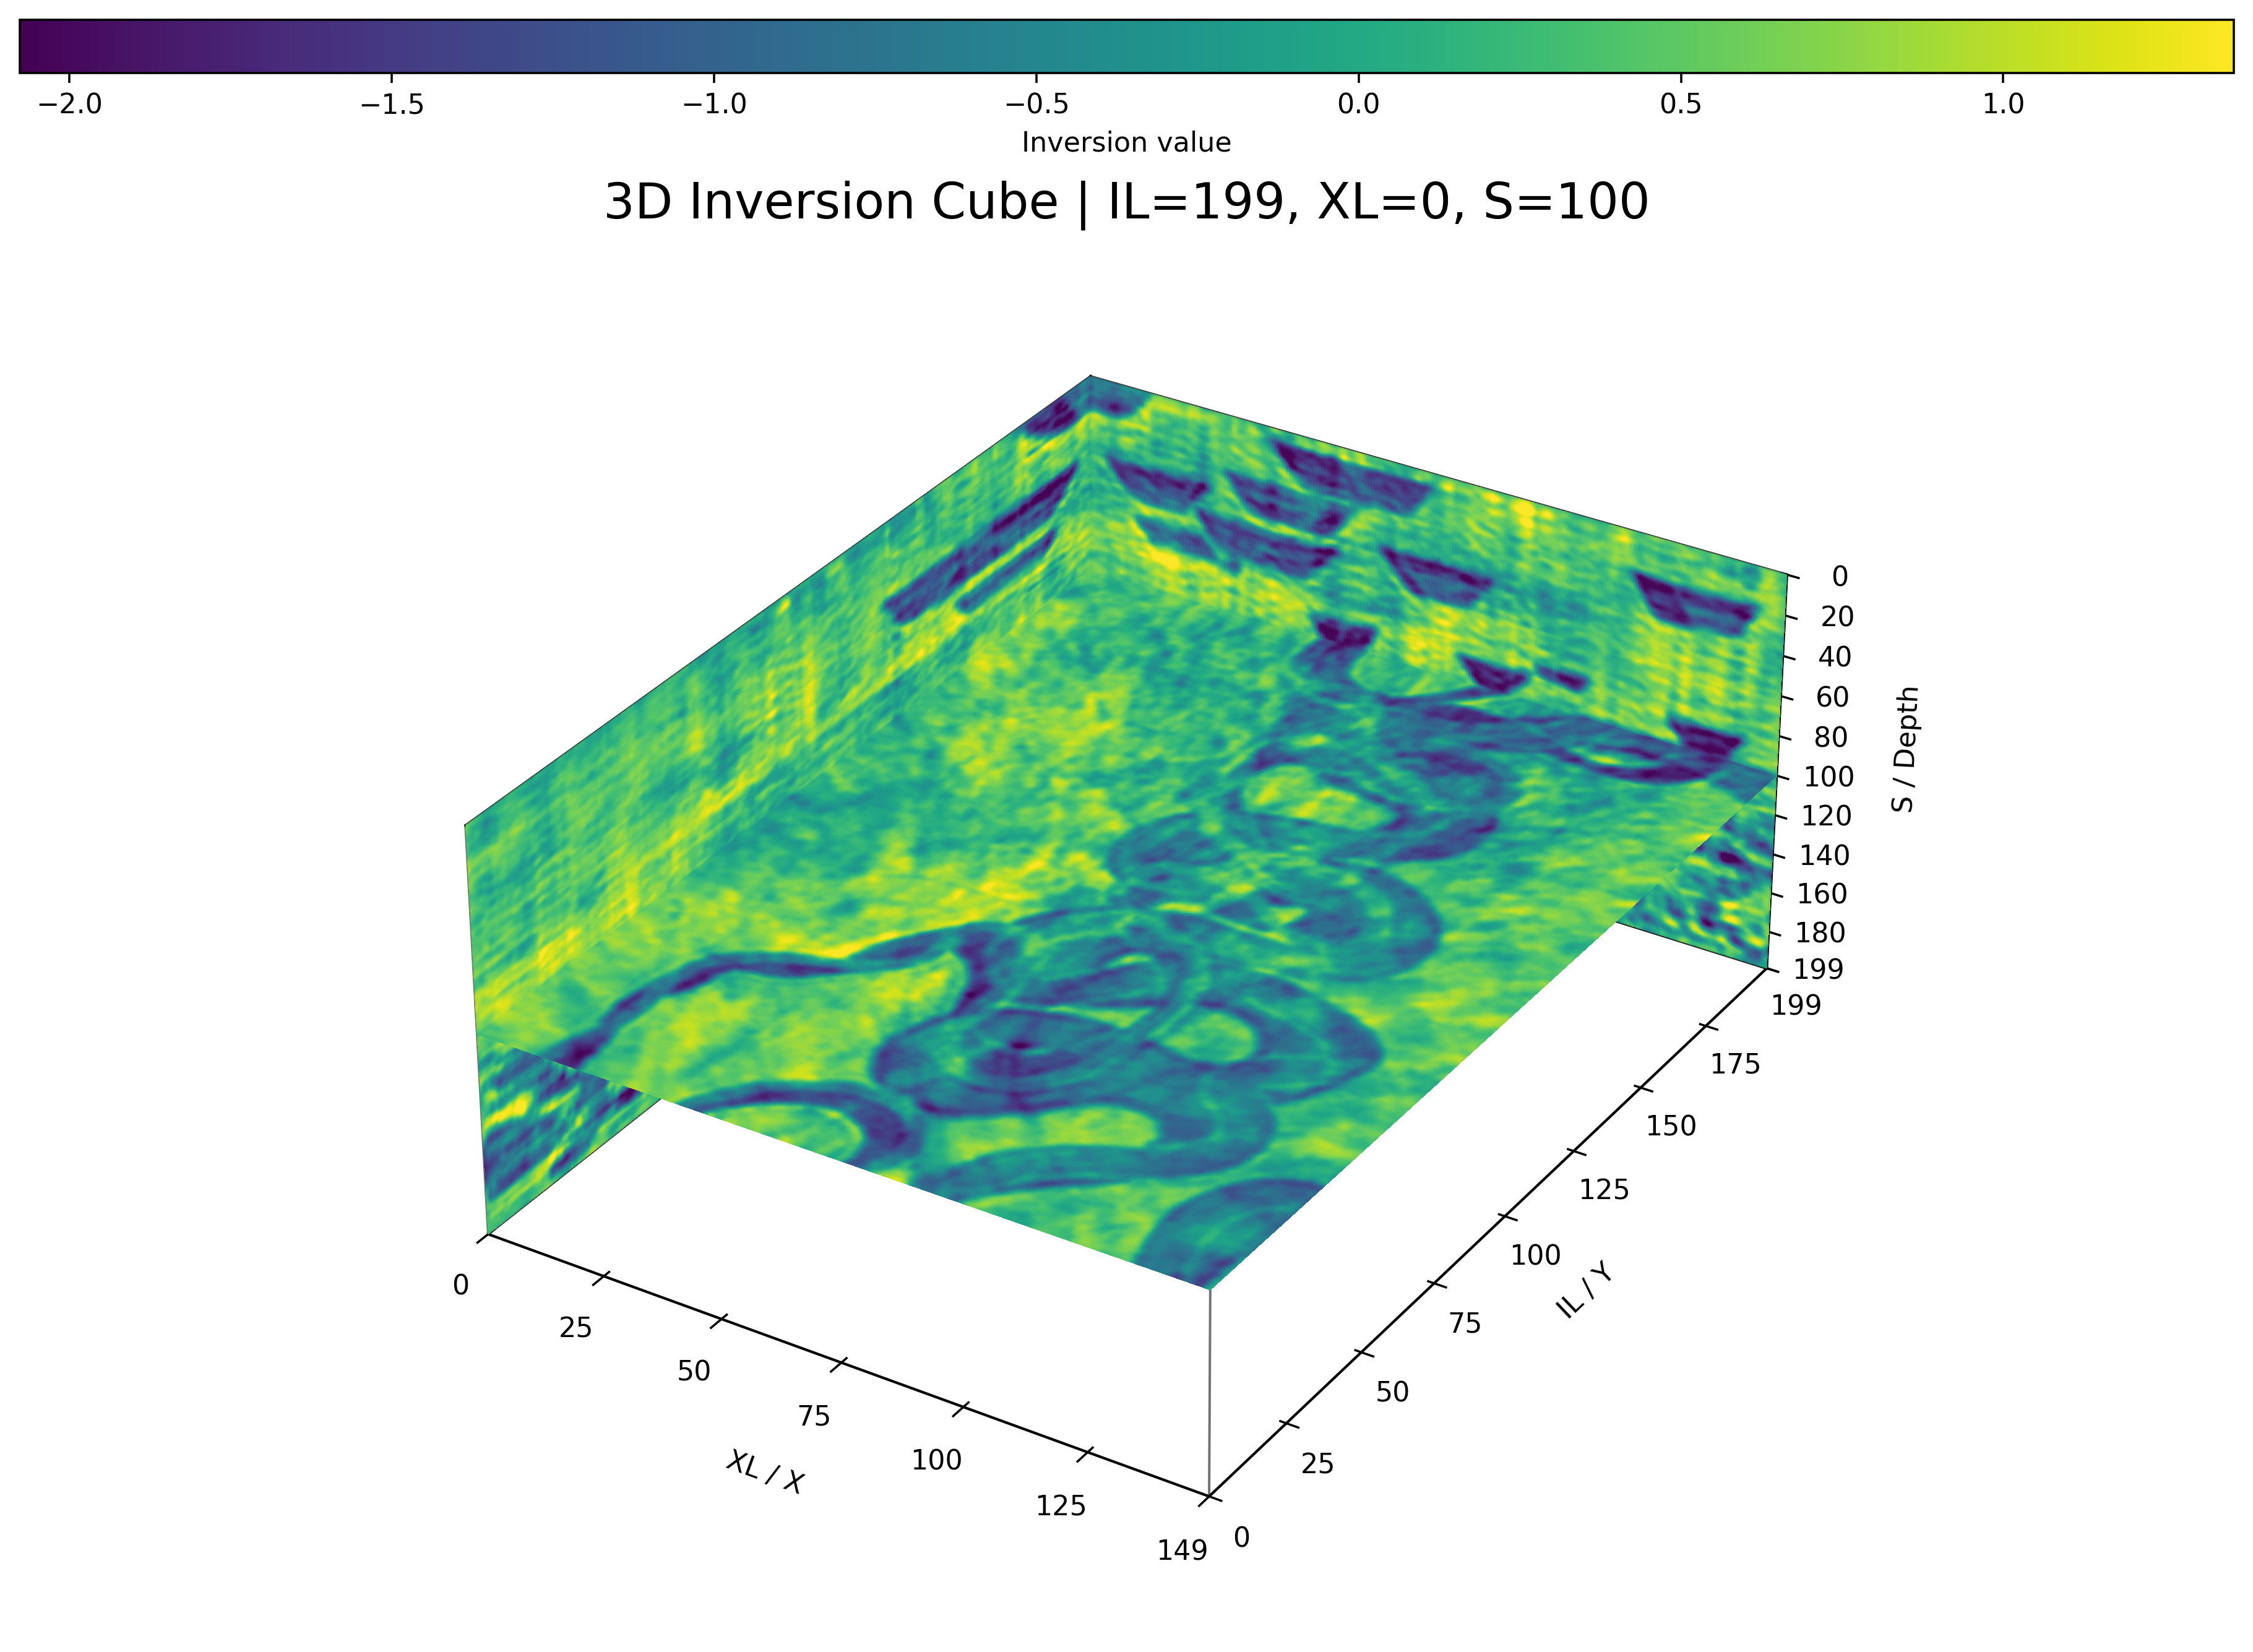

In [50]:
fig, ax = plot_cube_3slices(
    cube,
    il_slice=IL_SLICE,
    xl_slice=XL_SLICE,
    s_slice=S_SLICE,
    cmap=CMAP,
    vmin=VMIN,
    vmax=VMAX,
    robust_clip=ROBUST_CLIP,
    figsize=FIGSIZE,
    dpi=DPI,
    elev=ELEV,
    azim=AZIM,
    roll=ROLL,
    title=TITLE,
    show_colorbar=SHOW_COLORBAR,
    show_box=SHOW_BOX,
    display_in_index_units=DISPLAY_IN_INDEX_UNITS,
    x_tick_step_idx=X_TICK_STEP_IDX,
    y_tick_step_idx=Y_TICK_STEP_IDX,
    z_tick_step_idx=Z_TICK_STEP_IDX,
    smooth_factor=SURFACE_SMOOTH_FACTOR,
    horizontal_smooth_factor=HORIZONTAL_SMOOTH_FACTOR,
    smooth_order=SURFACE_SMOOTH_ORDER,
    gaussian_sigma=SURFACE_GAUSSIAN_SIGMA,
    max_surface_points=MAX_SURFACE_POINTS,
    vertical_aspect_scale=Z_ASPECT_SCALE,
    horizontal_alpha=HORIZONTAL_ALPHA,
    vertical_alpha=VERTICAL_ALPHA,
    output_png=OUTPUT_PNG,
)

